In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os
import sys

# Ensure data_utils is accessible
sys.path.append(os.path.abspath('.'))
import data_utils
import spod_utils

plt.rc('text', usetex=False)
plt.rc('font', family='serif', size=12)

# Create figures directory if it doesn't exist
os.makedirs('figures', exist_ok=True)


## Mathematical Framework: Energy Spectra Across All Runs

In a forced turbulent jet, the periodic actuation at a frequency $f_{act}$ introduces a fundamental mode into the flow field, characterized by a Strouhal number $St_{act} = f_{act} D / U_{\infty}$. Energy cascades into higher harmonics, resulting in coherent structures at integer multiples of the fundamental frequency ($2f_{act}$, $3f_{act}$, etc.).

**Important Note on Frequency Scaling**: The PIV acquisition system captures exactly 20 snapshots per actuation cycle for all forced runs. Therefore, in the raw non-dimensional time of the snapshots, the fundamental forcing frequency is always $1/20 = 0.05$ cycles/snapshot. To convert the SPOD frequency bins ($f_{dt}$) to the physical Strouhal number ($St$), we scale the frequencies by $St_{act} / 0.05$.

First, we will load the energy spectra ($\lambda_1$ vs $St$) for **all forced runs** (RUN 2 to RUN 25) to visualize the energy cascade globally. To prevent memory overload, we extract only the eigenvalues and frequencies using `load_spod_npz()`.


In [3]:
# Define St_act for all forced runs (Run 2 to 25)
all_runs_info = {i: 0.05 * (i - 1) for i in range(2, 26)}

spectra_results = {}

for run_idx, st_act in all_runs_info.items():
    spod_path = f'SPOD_data/RUN{run_idx}_PIV_SPOD.npz'
    if not os.path.exists(spod_path):
        print(f"File {spod_path} not found, skipping RUN {run_idx}.")
        continue
        
    # Load ONLY freqs and eigvals to save RAM
    freqs, eigvals = spod_utils.load_spod_npz(spod_path)
    
    # Scale freqs to physical Strouhal number
    freqs_st = freqs * (st_act / 0.05)
    
    spectra_results[run_idx] = {
        'st_act': st_act,
        'all_freqs': freqs_st,
        'all_energies': eigvals[:, 0], # Leading SPOD mode energy
    }
print(f"Loaded spectra for {len(spectra_results)} runs.")


Loaded spectra for 24 runs.


<>:34: SyntaxWarning: invalid escape sequence '\l'
<>:34: SyntaxWarning: invalid escape sequence '\l'
C:\Users\alefo\AppData\Local\Temp\ipykernel_11452\504737812.py:34: SyntaxWarning: invalid escape sequence '\l'
  ax.set_ylabel("SPOD Energy $\lambda_1$", fontsize=10)


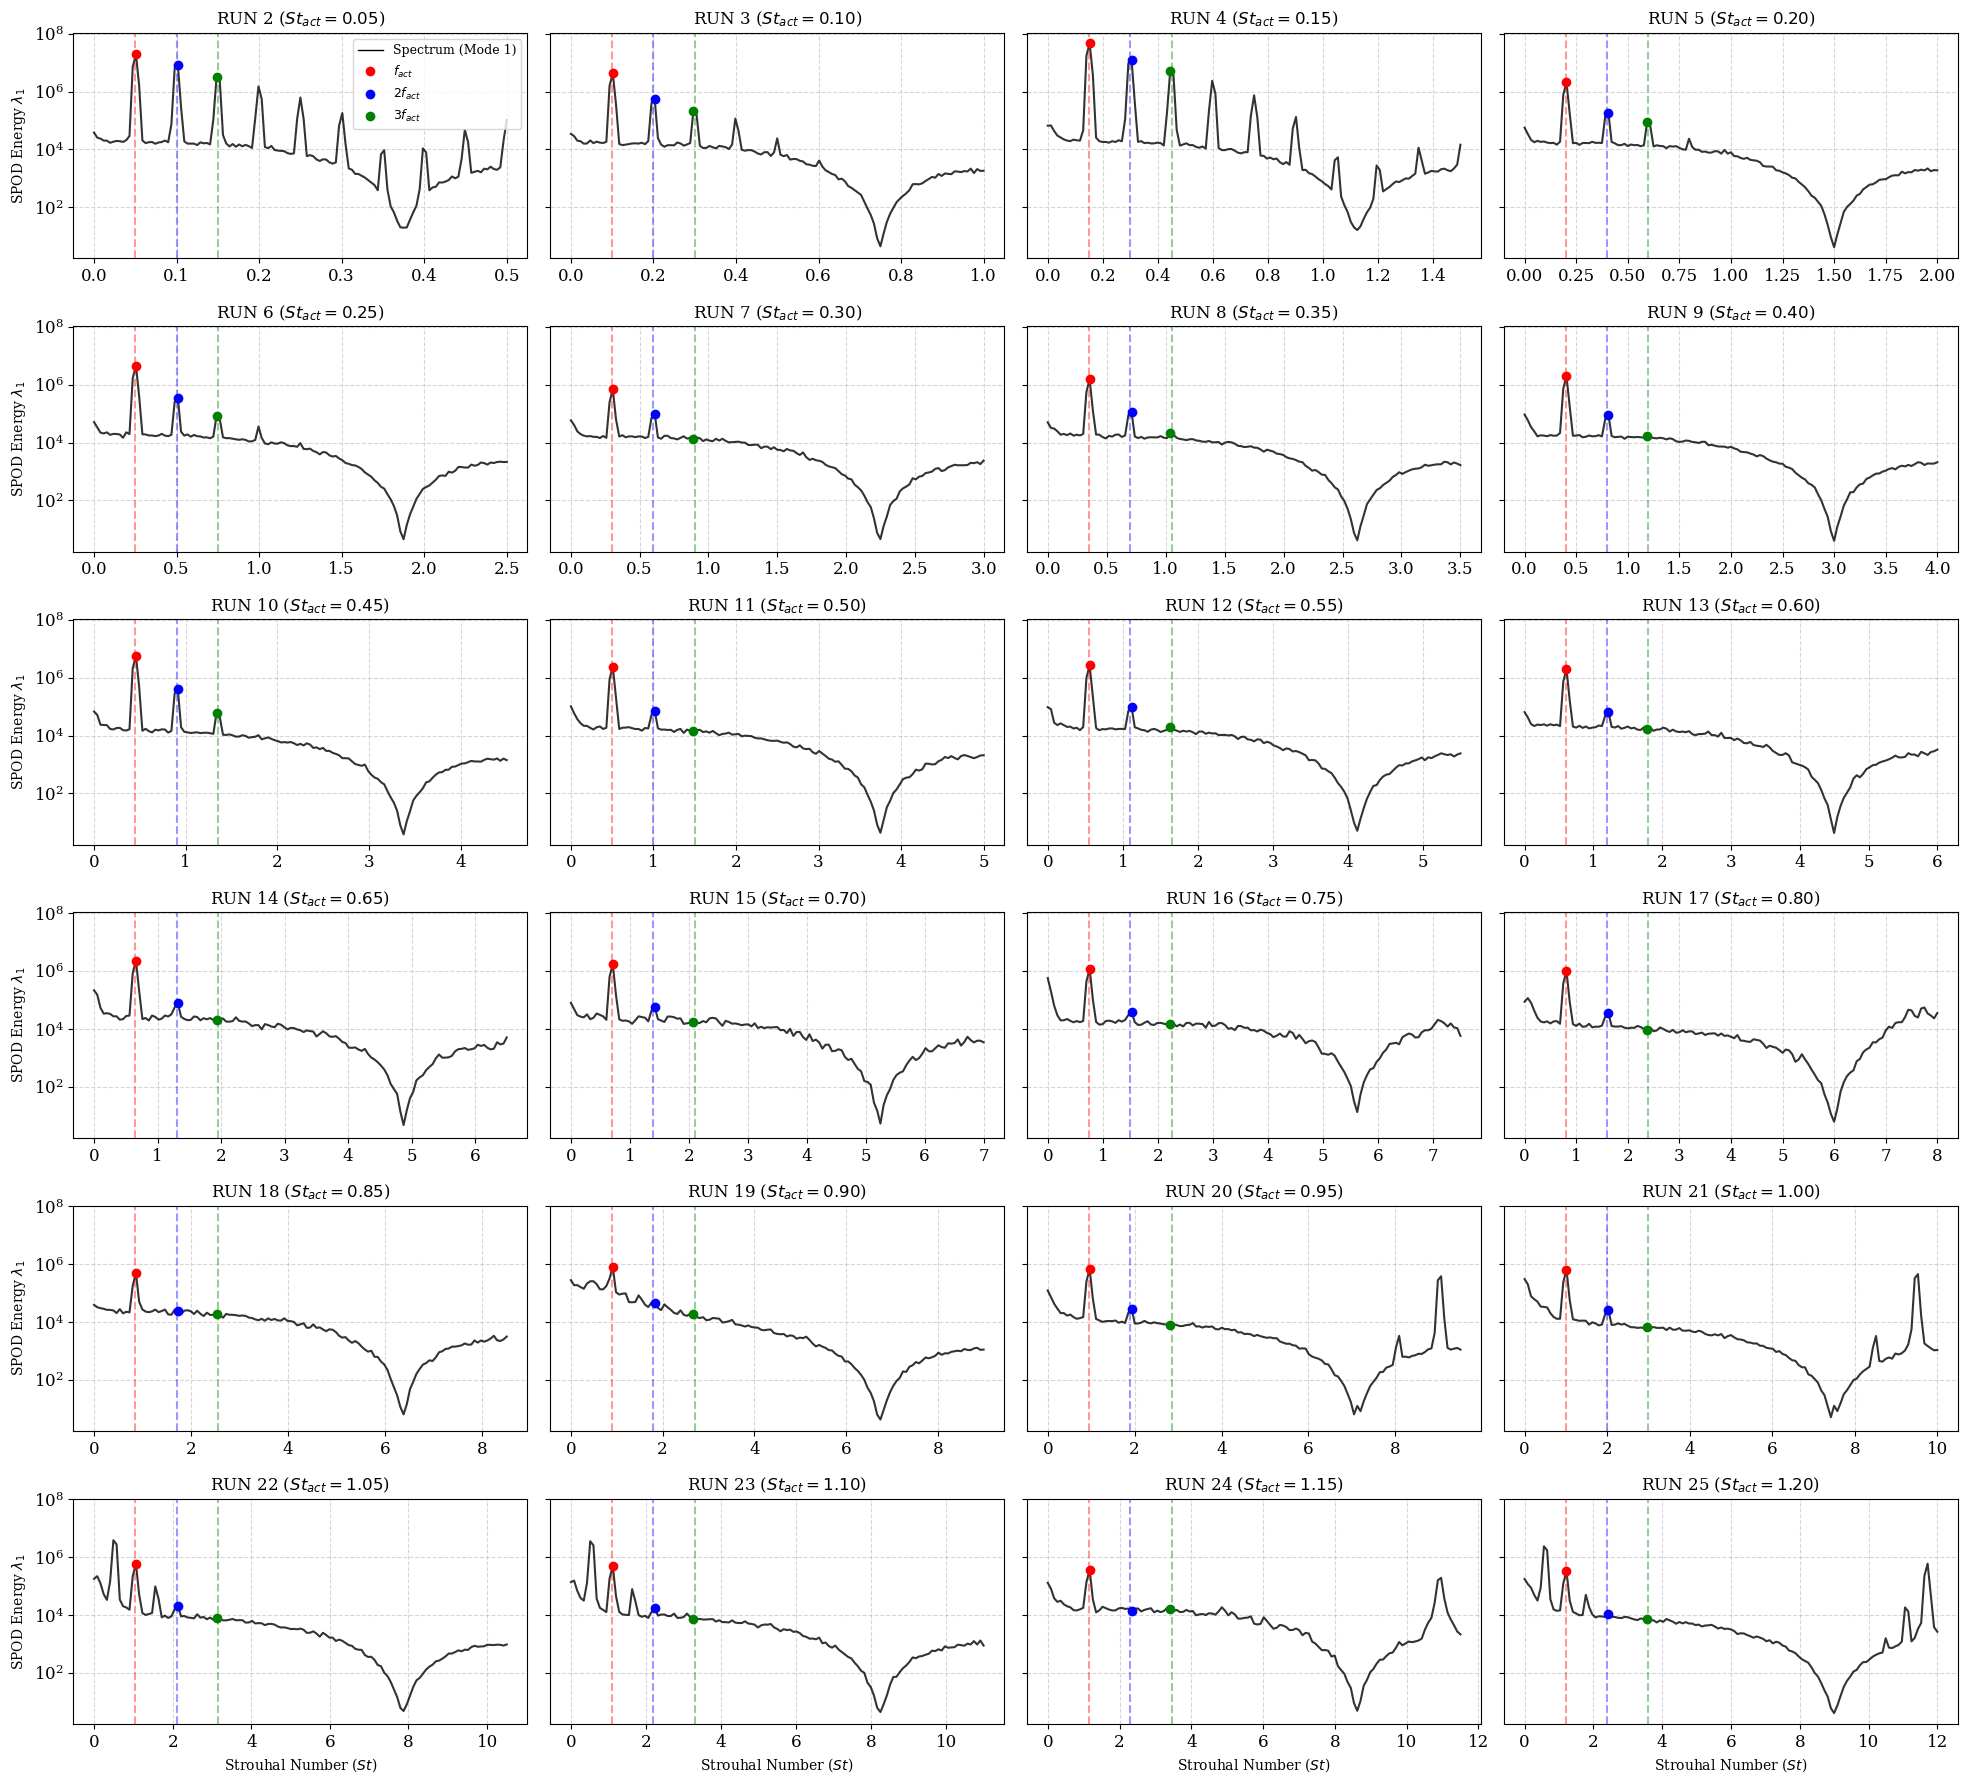

In [4]:
n_runs = len(spectra_results)
cols = 4
rows = int(np.ceil(n_runs / cols))

fig, axes = plt.subplots(rows, cols, figsize=(20, 3*rows), sharex=False, sharey=True)
axes = axes.flatten()

for i, (run_idx, res) in enumerate(spectra_results.items()):
    ax = axes[i]
    st_act = res['st_act']
    
    # Plot the full spectrum
    ax.plot(res['all_freqs'], res['all_energies'], 'k-', alpha=0.8)
    
    # Identify harmonics: f_act, 2f_act, 3f_act
    colors = ['r', 'b', 'g']
    target_strouhal = [st_act, 2*st_act, 3*st_act]
    
    for j, st in enumerate(target_strouhal):
        # Find closest frequency bin
        idx = np.argmin(np.abs(res['all_freqs'] - st))
        if j < len(colors):
            ax.plot(res['all_freqs'][idx], res['all_energies'][idx], 
                    marker='o', markersize=6, color=colors[j], linestyle='None')
            ax.axvline(st, color=colors[j], linestyle='--', alpha=0.4)
            
    ax.set_title(f"RUN {run_idx} ($St_{{act}}={st_act:.2f}$)", fontsize=12)
    ax.set_yscale('log')
    ax.grid(True, which="both", ls="--", alpha=0.5)
    
    if i >= n_runs - cols:
        ax.set_xlabel("Strouhal Number ($St$)", fontsize=10)
    if i % cols == 0:
        ax.set_ylabel("SPOD Energy $\lambda_1$", fontsize=10)

# Hide any extra empty subplots
for i in range(n_runs, len(axes)):
    axes[i].set_visible(False)

# Add a custom legend to the first plot
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='k', lw=1, label='Spectrum (Mode 1)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='r', markersize=8, label='$f_{act}$'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='b', markersize=8, label='$2f_{act}$'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='g', markersize=8, label='$3f_{act}$')
]
axes[0].legend(handles=legend_elements, loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig('figures/all_runs_spectra.png', dpi=300, bbox_inches='tight')
plt.show()


## Spatial Structure of Harmonics (Selected Runs)

Now that we have visualized the energy cascade globally, we will examine the spatial morphology of these harmonics. To prevent memory overflow, we will load the full `eigvecs` array only for a subset of representative runs: RUN 4 ($St=0.15$), RUN 7 ($St=0.30$), RUN 10 ($St=0.45$), and RUN 13 ($St=0.60$).

**Note on Visualization**: SPOD spatial modes are mathematically normalized to have a spatial norm of 1. Consequently, highly concentrated modes will exhibit very large local magnitudes (to sum up to 1), whereas diffuse modes will have smaller magnitudes everywhere. To prevent concentrated modes from creating massively long, cluttered arrows in the quiver plot, we divide the vector field in each subplot by its own maximum magnitude (`u_real / mag.max()`). This guarantees that the longest arrow in every single subplot is exactly the same length, providing a clean visualization of the structure's shape and direction while relying on the contour colormap to convey the absolute magnitude.


In [5]:
# Define selected runs for spatial visualization
selected_runs = {2: 0.05, 4: 0.15, 6: 0.25, 10: 0.45}

# Load spatial grid
grid = np.load('spatial_grid.npz')
X = grid['X_grid']
Y = grid['Y_grid']

modes_results = {}
for run_idx, st_act in selected_runs.items():
    spod_path = f'SPOD_data/RUN{run_idx}_PIV_SPOD.npz'
    if not os.path.exists(spod_path):
        continue
        
    spod_data = np.load(spod_path)
    
    # Scale frequencies
    freqs_st = spod_data['freqs'] * (st_act / 0.05)
    eigvecs = spod_data['eigvecs']
    
    target_strouhal = [st_act, 2*st_act, 3*st_act]
    harmonic_labels = ["$f_{act}$", "$2f_{act}$", "$3f_{act}$"]
    
    run_res = {'freqs': [], 'modes': [], 'labels': harmonic_labels}
    for st in target_strouhal:
        idx = np.argmin(np.abs(freqs_st - st))
        run_res['freqs'].append(freqs_st[idx])
        run_res['modes'].append(eigvecs[idx, 0])
        
    modes_results[run_idx] = run_res
    print(f"Extracted spatial modes for RUN {run_idx}")


Extracted spatial modes for RUN 2
Extracted spatial modes for RUN 4
Extracted spatial modes for RUN 6
Extracted spatial modes for RUN 10


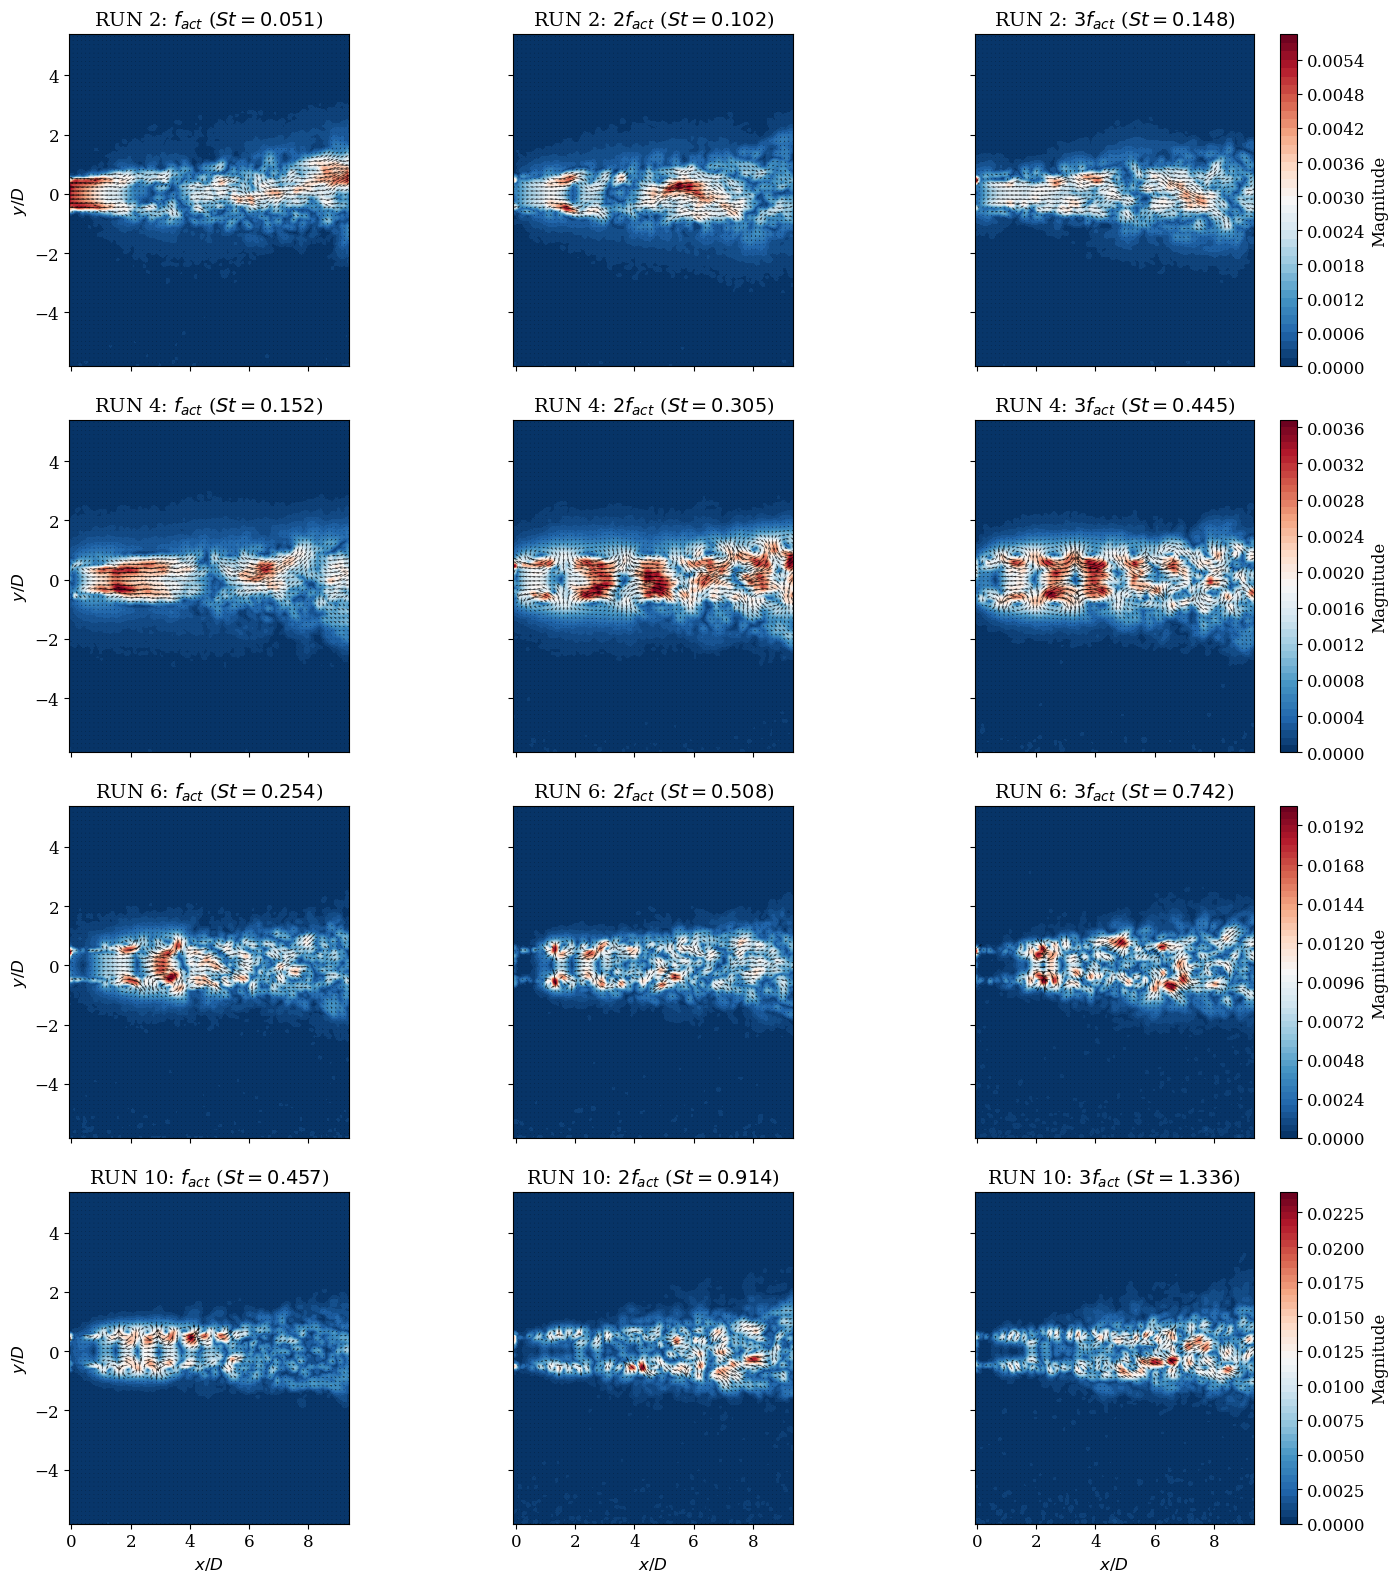

In [8]:
quiver_step = 4
scale = 20.0 # Adjusted scale since maximum arrow length is now exactly 1
n_sel_runs = len(modes_results)

# Create a figure for visual comparison: Rows = Runs, Columns = Harmonics (f_act, 2f_act, 3f_act)
fig, axes = plt.subplots(n_sel_runs, 3, figsize=(15, 4*n_sel_runs), sharex=True, sharey=True)

for i, (run_idx, res) in enumerate(modes_results.items()):
    for j in range(3):
        ax = axes[i, j]
        mode = res['modes'][j]
        u_mode, v_mode = mode[:X.size].reshape(X.shape), mode[X.size:].reshape(X.shape)
        
        # Real part for visualization
        u_real = np.real(u_mode)
        v_real = np.real(v_mode)
        mag = np.sqrt(u_real**2 + v_real**2)
        
        # Normalize the vectors by the maximum magnitude in THIS specific subplot
        # This guarantees the maximum arrow length is exactly 1 across all subplots, eliminating clutter.
        max_mag = mag.max()
        u_plot = u_real / max_mag
        v_plot = v_real / max_mag
        
        # The contourf still uses the true absolute magnitude to provide correct color context
        cont = ax.contourf(X, Y, mag, cmap='RdBu_r', levels=50)
        if j == 2:
            plt.colorbar(cont, ax=ax, label="Magnitude")
            
        ax.quiver(
            X[::quiver_step, ::quiver_step],
            Y[::quiver_step, ::quiver_step],
            u_plot[::quiver_step, ::quiver_step],
            v_plot[::quiver_step, ::quiver_step],
            scale=scale, color='k', alpha=0.7
        )
        
        ax.set_title(f"RUN {run_idx}: {res['labels'][j]} ($St={res['freqs'][j]:.3f}$)", fontsize=14)
        ax.set_aspect('equal')
        
        if j == 0:
            ax.set_ylabel("$y/D$", fontsize=12)
        if i == n_sel_runs - 1:
            ax.set_xlabel("$x/D$", fontsize=12)

plt.tight_layout()
plt.savefig('figures/cross_run_harmonics_modes.png', dpi=300, bbox_inches='tight')
plt.show()
